In [1]:
'''
Loads the MELCHIORS catalogue.
Converts RA/Dec into astropy.coordinates.SkyCoord.
Filters to Dec > -50°.
Examines every target over January–June 2027.
Calculates altitude and airmass from La Palma.
Requires airmass ≤ 1.2.
Requires the star to be above the horizon and the Sun sufficiently below the horizon.
Reports the best observing time for every candidate.
Calculates Moon separation, but does not use it as a filter yet.
Saves the result as a CSV.
'''


'\nLoads the MELCHIORS catalogue.\nConverts RA/Dec into astropy.coordinates.SkyCoord.\nFilters to Dec > -50°.\nExamines every target over January–June 2027.\nCalculates altitude and airmass from La Palma.\nRequires airmass ≤ 1.2.\nRequires the star to be above the horizon and the Sun sufficiently below the horizon.\nReports the best observing time for every candidate.\nCalculates Moon separation, but does not use it as a filter yet.\nSaves the result as a CSV.\n'

In [2]:
from extracting import *

YEAR = 2027

MIN_DECLINATION = -30.0
MAX_AIRMASS = 1.5
MIN_ALTITUDE = 30.0
MAX_SUN_ALTITUDE = -18.0
TIME_STEP_MINUTES = 15
MIN_CONTINUOUS_HOURS = 6.0
MIN_MOON_SEPARATION_DEG = 60.0


## 1. Load catalogue

In [3]:
# Load and filter catalogue
df = load_catalogue(CATALOGUE_FILE)
df = spectral_type_filter(df)
df = declination_filter(df)
df

Catalogue columns: ['obsID', 'Vmag', 'B-V', 'SpType', 'ra', 'dec', 'airmass', 'exptime', 'SNR-V', 'date-avg', 'FileName']
Total rows: 3,256
Unique stars: 2,096
OBA-type stars: 880
After dec > -30.0°: 879


,obsID,Vmag,B-V,SpType,ra,dec,airmass,exptime,SNR-V,date-avg,FileName
0,307233,4.52,0.05,A2V,00:18:19.70,+36:47:06.79,1.261,81.0,209.3,2010-09-28T03:59:52,me307233.fit
2,307238,5.57,0.40,A8II,00:01:37.00,+61:13:22.12,1.553,500.0,317.2,2010-09-28T04:43:18,me307238.fit
4,307340,6.77,0.19,A5/7III,02:29:55.40,-22:40:59.52,1.820,1800.0,279.0,2010-09-29T05:04:50,me307340.fit
11,307473,6.77,0.19,A5/7III,02:29:55.30,-22:40:59.52,1.603,700.0,160.0,2010-10-01T03:09:56,me307473.fit
13,307478,5.88,-0.02,A0IV,00:18:38.30,+31:31:01.99,1.443,300.0,191.5,2010-10-01T04:29:10,me307478.fit
...,...,...,...,...,...,...,...,...,...,...,...
3250,957486,4.63,-0.11,B7V,07:35:22.89,-28:22:09.55,1.937,91.0,199.0,2020-02-11T00:28:08,me957486.fit
3251,957613,7.46,-0.18,B1III,07:19:09.91,-25:33:57.20,1.869,900.0,148.7,2020-02-12T00:34:22,me957613.fit
3252,957614,6.26,-0.15,B2III,06:59:39.25,-21:36:10.37,1.875,350.0,158.6,2020-02-12T00:47:05,me957614.fit
3253,957615,6.61,-0.01,A0IV,07:26:40.68,-23:42:45.40,1.865,529.0,157.5,2020-02-12T00:56:42,me957615.fit


In [4]:
# Calculate visibility with continuity constraint
df, nights, n_nights, n_times, visibility_per_night, continuous_hours_grid = calculate_visibility(df)


Calculating visibility for 879 stars over 181 nights...
  Processing night 1/181: 2027-01-01
  Processing night 31/181: 2027-01-31
  Processing night 61/181: 2027-03-02
  Processing night 91/181: 2027-04-01
  Processing night 121/181: 2027-05-01
  Processing night 151/181: 2027-05-31
  Processing night 181/181: 2027-06-30

Visibility calculation complete.


In [5]:
heatmap = compute_heatmap(df, n_nights, n_times, visibility_per_night, continuous_hours_grid)



Building heatmap...

Heatmap built.


In [6]:
# Filter: require >= MIN_CONTINUOUS_HOURS continuous
print(f"\nFiltering for ≥{MIN_CONTINUOUS_HOURS} continuous hours...")
df_good = df[df["best_continuous_hours"] >= MIN_CONTINUOUS_HOURS].copy()
print(f"Stars with ≥{MIN_CONTINUOUS_HOURS}h continuous: {len(df_good)}")
df_good


Filtering for ≥6.0 continuous hours...
Stars with ≥6.0h continuous: 54


,obsID,Vmag,B-V,SpType,ra,dec,airmass,exptime,SNR-V,date-avg,FileName,best_continuous_hours,best_altitude_deg,best_airmass,best_observing_time_utc,best_moon_separation_deg,best_month
108,327246,1.86,-0.19,B3V,13:47:32.40,+49:18:47.81,1.068,20.0,175.1,2011-01-13T07:31:06,me327246.fit,7.75,69.575841,1.067082,2027-04-19 01:15:00.000,60.279929,4
124,327341,2.20,Nan,A1V,13:23:55.20,+54:55:25.00,1.118,31.5,289.0,2011-01-14T07:28:33,me327341.fit,7.75,63.972159,1.112866,2027-04-04 01:45:00.000,60.820607,4
141,327561,3.02,0.19,A7IV+(n),14:32:04.70,+38:18:29.70,1.018,56.5,275.4,2011-01-16T07:40:12,me327561.fit,6.50,80.567288,1.013707,2027-05-19 00:00:00.000,60.140672,5
158,327657,4.71,-0.09,B9III,16:02:47.90,+46:02:12.08,1.137,250.0,202.7,2011-01-17T07:36:25,me327657.fit,7.50,72.750810,1.047094,2027-05-21 01:15:00.000,66.167305,5
174,327764,4.20,-0.02,B9V,16:34:06.20,+42:26:13.31,1.296,146.0,263.3,2011-01-18T06:52:53,me327764.fit,7.00,76.357398,1.029033,2027-05-22 01:45:00.000,63.401959,5
249,328668,5.76,0.15,A8III,10:18:02.00,+65:06:30.10,1.256,520.0,194.1,2011-02-03T03:35:07,me328668.fit,7.00,53.769054,1.239709,2027-03-10 00:15:00.000,61.744032,3
250,328669,6.09,0.16,A7III,10:30:26.60,+64:15:27.72,1.243,800.0,226.5,2011-02-03T03:49:14,me328669.fit,7.00,54.621529,1.226474,2027-03-09 00:45:00.000,60.106318,3
294,336199,3.87,-0.14,B5IV,16:19:44.40,+46:18:48.10,1.206,300.0,212.9,2011-03-10T03:55:01,me336199.fit,7.25,72.489618,1.048589,2027-05-22 01:30:00.000,66.847072,5
298,336615,2.22,0.05,A1.5Vas,13:23:55.50,+54:55:31.30,1.184,687.3,240.2,2011-03-21T01:03:12,me336615.fit,7.75,63.970390,1.112883,2027-04-04 01:45:00.000,60.822449,4
301,340247,4.70,0.31,A9IImF2,13:17:32.50,+40:34:21.40,1.049,120.0,209.3,2011-03-26T03:21:01,me340247.fit,6.25,78.280560,1.021290,2027-05-04 23:45:00.000,60.302320,5


In [7]:
# Sort by best airmass (lowest = best)
df_good = df_good.sort_values("best_airmass", ascending=True)

# Print summary
columns = []
for col in [
    "obsID", "Vmag", "SpType", "ra", "dec",
    "best_altitude_deg", "best_airmass",
    "best_continuous_hours", "best_observing_time_utc",
    "best_moon_separation_deg", "best_month",
]:
    if col in df_good.columns:
        columns.append(col)

print(f"\nTop candidates ({min(30, len(df_good))} shown):")
print(df_good[columns].head(30).to_string(index=False))


Top candidates (30 shown):
 obsID  Vmag        SpType          ra          dec  best_altitude_deg  best_airmass  best_continuous_hours best_observing_time_utc  best_moon_separation_deg  best_month
473549  6.05         B8III 19:43:54.00 +34:10:00.98          84.516636      1.004597                   6.00 2027-06-29 02:30:00.000                 60.031138           6
369497  4.72          B3IV 19:31:46.30 +34:27:10.69          84.234961      1.005084                   6.00 2027-06-26 02:30:00.000                 60.431065           6
477345  5.25          B6IV 19:07:18.10 +36:06:00.61          82.613140      1.008369                   6.50 2027-06-27 02:00:00.000                 60.394698           6
477343  6.08          B6IV 18:51:36.50 +36:32:20.69          82.153754      1.009451                   6.75 2027-06-26 01:45:00.000                 60.437657           6
369489  4.17 A0III+B9.5IVn 17:23:40.90 +37:08:45.38          81.631618      1.010762                   7.00 2027-06-08 01:


Histogram saved: telluric_standards_month_histogram_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


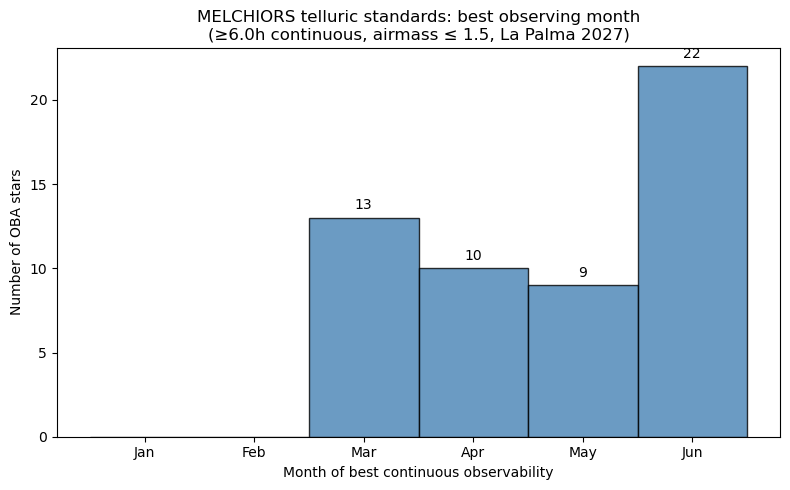

In [8]:
plot_month_histogram(df_good)



Heatmap saved: telluric_visibility_heatmap_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


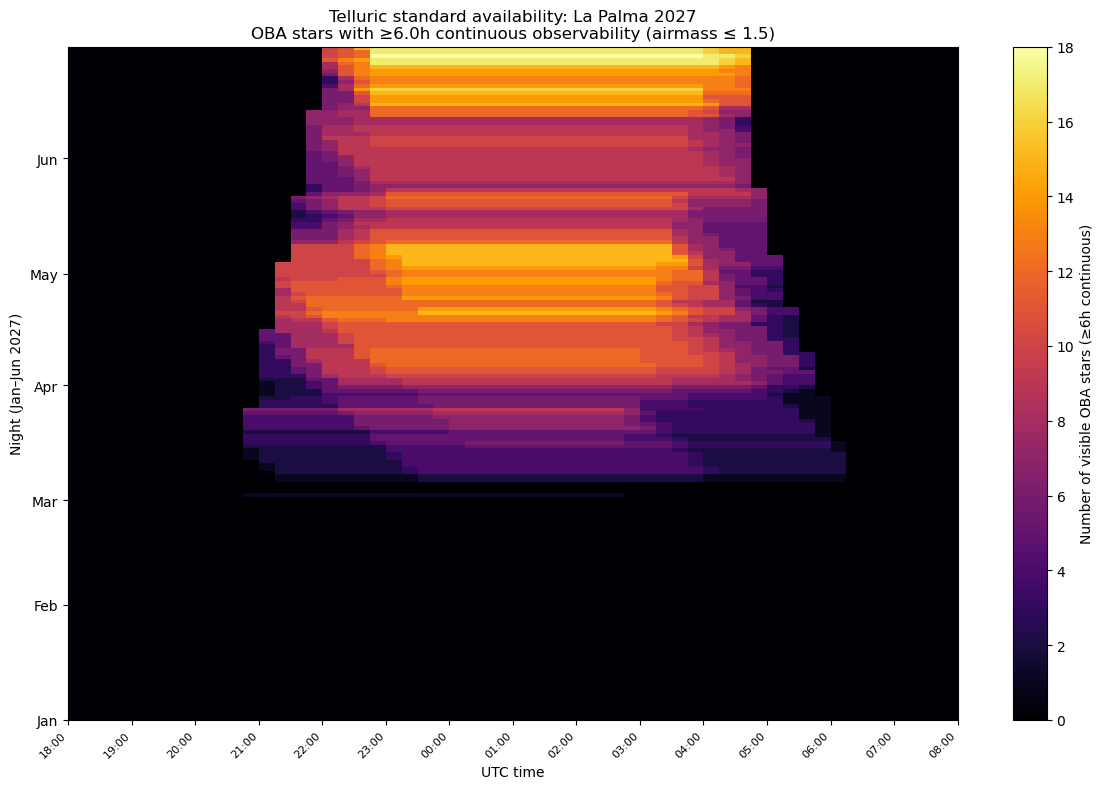

In [9]:
plot_visibility_heatmap(heatmap, nights)


Saved: stars_per_night_Jan_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


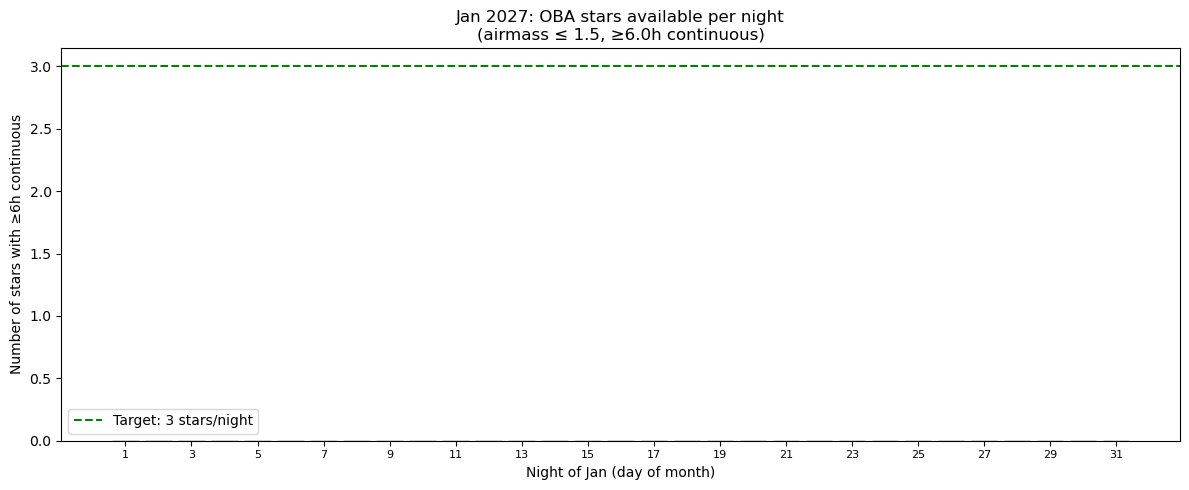

Saved: stars_per_night_Feb_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


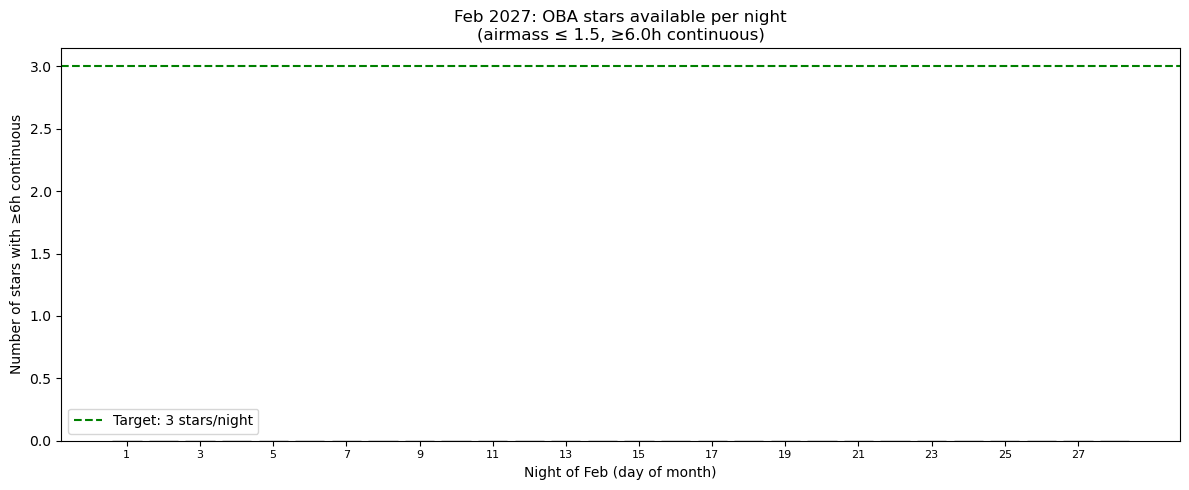

Saved: stars_per_night_Mar_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


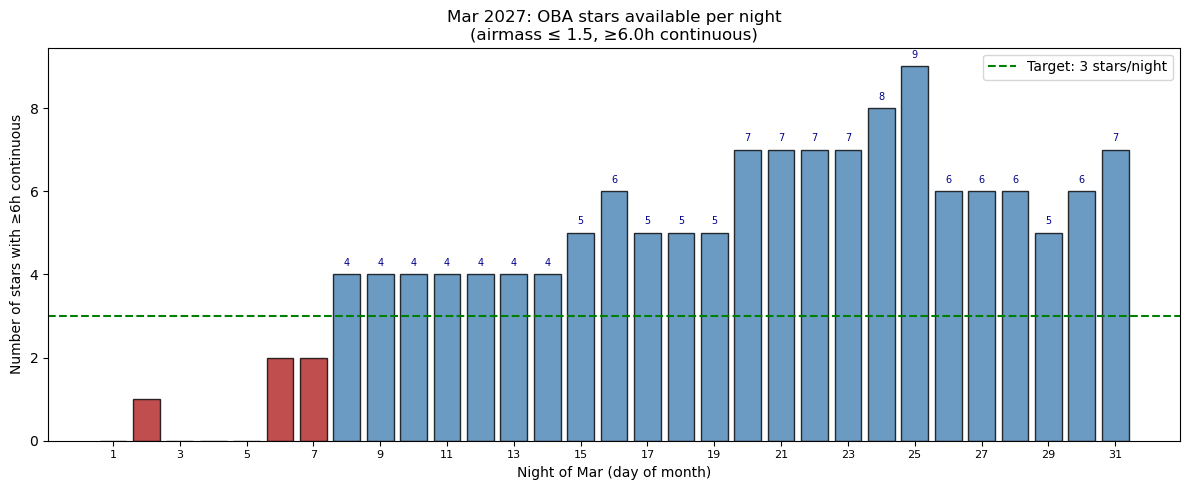

Saved: stars_per_night_Apr_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


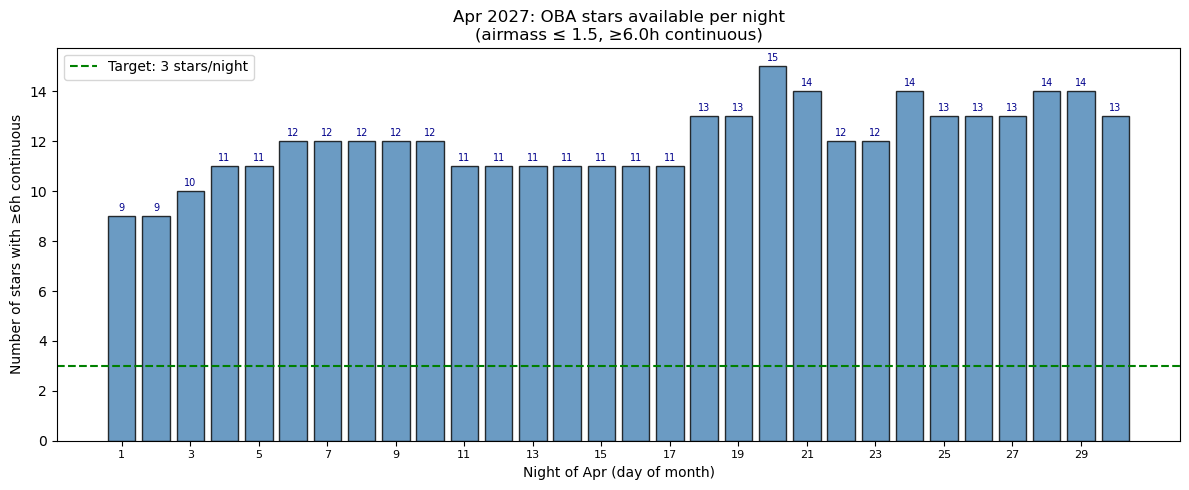

Saved: stars_per_night_May_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


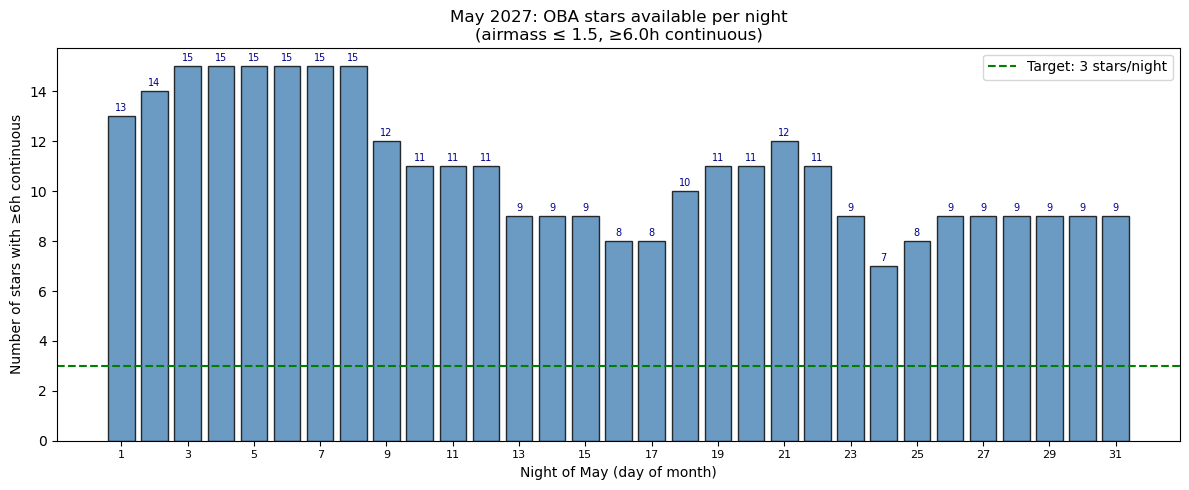

Saved: stars_per_night_Jun_alt30.0_am1.5_dec-30.0_sun-18.0_moon60.0_step15min_cont6.0h.pdf


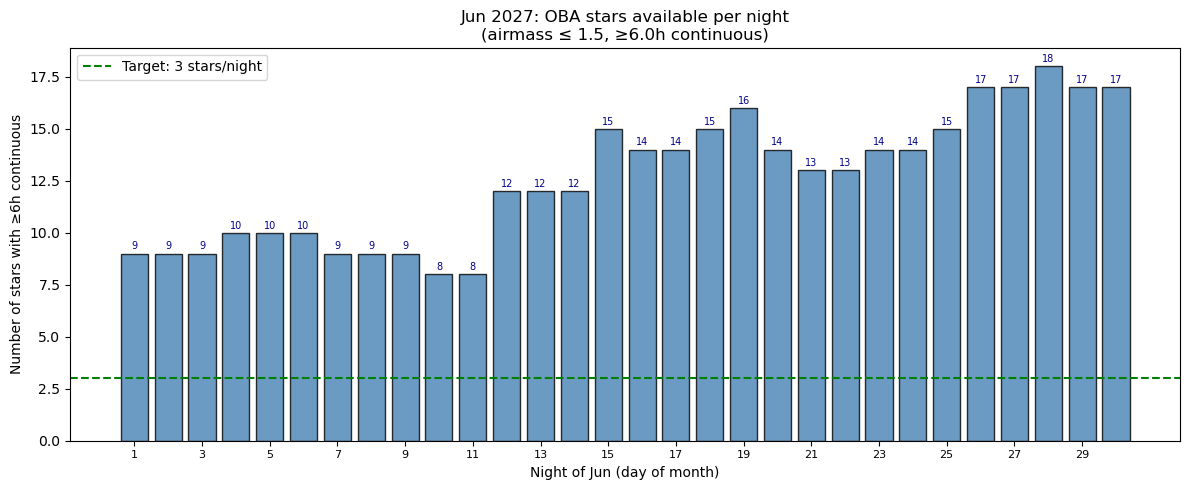


Nights with ≥3 stars available (good for 2-3 day observing runs):
  2027-03-08  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-09  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-10  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-11  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-12  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-13  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-14  (Mar): 4 stars — 328668, 328669, 347422, 349382
  2027-03-15  (Mar): 5 stars — 328668, 328669, 340647, 347422, 349382
  2027-03-16  (Mar): 6 stars — 328668, 328669, 340647, 347422, 349382, 350658
  2027-03-17  (Mar): 5 stars — 328668, 328669, 347422, 349382, 350658
  2027-03-18  (Mar): 5 stars — 328668, 328669, 347422, 349382, 350658
  2027-03-19  (Mar): 5 stars — 328668, 328669, 340647, 347422, 349382
  2027-03-20  (Mar): 7 stars — 328668, 328669, 340647, 347422, 349382, 391621, 391622
  2027-03-21  (Mar): 7 stars — 328668, 328669, 340647, 

In [10]:
## per month

plot_stars_per_night_by_month(df, nights, continuous_hours_grid)


 '2027-03-13 18:30:00.000' '2027-03-13 18:45:00.000'
 '2027-03-13 19:00:00.000' '2027-03-13 19:15:00.000'
 '2027-03-13 19:30:00.000' '2027-03-13 19:45:00.000'
 '2027-03-13 20:00:00.000' '2027-03-13 20:15:00.000'
 '2027-03-13 20:30:00.000' '2027-03-13 20:45:00.000'
 '2027-03-13 21:00:00.000' '2027-03-13 21:15:00.000'
 '2027-03-13 21:30:00.000' '2027-03-13 21:45:00.000'
 '2027-03-13 22:00:00.000' '2027-03-13 22:15:00.000'
 '2027-03-13 22:30:00.000' '2027-03-13 22:45:00.000'
 '2027-03-13 23:00:00.000' '2027-03-13 23:15:00.000'
 '2027-03-13 23:30:00.000' '2027-03-13 23:45:00.000'
 '2027-03-14 00:00:00.000' '2027-03-14 00:15:00.000'
 '2027-03-14 00:30:00.000' '2027-03-14 00:45:00.000'
 '2027-03-14 01:00:00.000' '2027-03-14 01:15:00.000'
 '2027-03-14 01:30:00.000' '2027-03-14 01:45:00.000'
 '2027-03-14 02:00:00.000' '2027-03-14 02:15:00.000'
 '2027-03-14 02:30:00.000' '2027-03-14 02:45:00.000'
 '2027-03-14 03:00:00.000' '2027-03-14 03:15:00.000'
 '2027-03-14 03:30:00.000' '2027-03-14 03:45:0


Trajectory plot saved: trajectory_349382_2027-03-13.pdf


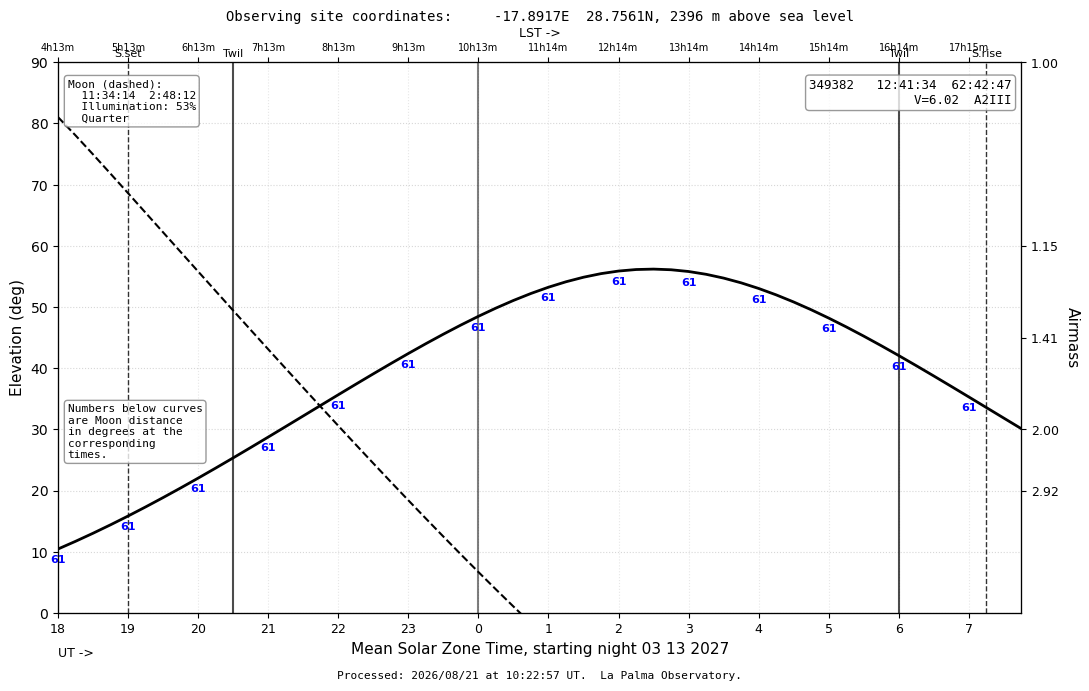

(<Figure size 1100x700 with 3 Axes>,
 <Axes: title={'center': 'Observing site coordinates:     -17.8917E  28.7561N, 2396 m above sea level'}, xlabel='Mean Solar Zone Time, starting night 03 13 2027', ylabel='Elevation (deg)'>)

In [11]:
sid = get_star_idx(df, 349382)
nid = get_best_night_idx(df, nights, 349382)
plot_night_trajectory(df, nights, star_idx=sid, night_idx=nid)


In [12]:
# # --------------------------------------------------------
# # Save
# # --------------------------------------------------------

# observable.to_csv(
#     OUTPUT_FILE,
#     index=False,
# )

# print(
#     f"\nSaved results to:"
#     f"\n{OUTPUT_FILE}"
# )
